In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!nvidia-smi
!nvcc --version


Mon Aug 17 23:30:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import torch
print(torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")


2.10.0+cu128 True Tesla T4


## Common config
Full spec: B=8, NH=16, D=64, float16. On the 16GB T4/P100, Part A can OOM at very large N (it materializes the full N x N matrix) -- we catch that and skip rather than crash.

In [5]:
import math, time, csv, os
import torch

B, NH, D = 8, 16, 64
SEQ_LENS = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

def make_qkv(N, batch=B, heads=NH, dim=D, device=DEVICE, dtype=DTYPE, seed=0):
    g = torch.Generator(device="cpu").manual_seed(seed)
    Q = torch.randn(batch, heads, N, dim, generator=g).to(device=device, dtype=dtype)
    K = torch.randn(batch, heads, N, dim, generator=g).to(device=device, dtype=dtype)
    V = torch.randn(batch, heads, N, dim, generator=g).to(device=device, dtype=dtype)
    return Q, K, V

def time_fn(fn, iters=10, warmup=2):
    for _ in range(warmup):
        fn()
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(iters):
        fn()
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    end = time.perf_counter()
    return (end - start) / iters * 1000.0

def max_abs_diff(a, b):
    return (a.float() - b.float()).abs().max().item()

def safe_run(fn, N, label, iters=10):
    """Runs fn, catches CUDA OOM so a big N doesn't kill the whole sweep."""
    try:
        ms = time_fn(fn, iters=iters)
        print(f"[{label}] N={N:5d}  {ms:8.3f} ms")
        return ms
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        print(f"[{label}] N={N:5d}  OOM - skipped")
        return None


## Part A: Standard Attention (PyTorch)
Full `torch.matmul` + `torch.softmax`, explicit N x N matrix. Expect OOM around N=4096-8192 even on 16GB -- that's expected and worth noting in the write-up.

In [6]:
def standard_attention(Q, K, V):
    scale = 1.0 / math.sqrt(D)
    scores = torch.matmul(Q, K.transpose(-2, -1)) * scale
    probs = torch.softmax(scores, dim=-1)
    return torch.matmul(probs, V)

results_a = []
for N in SEQ_LENS:
    Q, K, V = make_qkv(N)
    ms = safe_run(lambda: standard_attention(Q, K, V), N, "Part A")
    if ms is not None:
        results_a.append((N, ms))
    del Q, K, V
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


[Part A] N=   32     0.100 ms
[Part A] N=   64     0.120 ms
[Part A] N=  128     0.222 ms
[Part A] N=  256     0.651 ms
[Part A] N=  512     2.368 ms
[Part A] N= 1024     9.120 ms
[Part A] N= 2048    31.757 ms
[Part A] N= 4096   142.073 ms
[Part A] N= 8192  OOM - skipped


## Part B: FlashAttention, Python-level tiling
Never materializes the full matrix -- scales further than Part A but is slow (Python for-loops), so we cap timing at a smaller max N.

In [7]:
M_SRAM = 32 * 1024
Bc = M_SRAM // (4 * D)
Br = min(Bc, D)
print("Bc =", Bc, " Br =", Br)

def flash_attention_python(Q, K, V):
    Bsz, NHh, N, d = Q.shape
    scale = 1.0 / math.sqrt(d)
    Tc = (N + Bc - 1) // Bc
    Tr = (N + Br - 1) // Br

    O = torch.zeros_like(Q, dtype=torch.float32)
    m = torch.full((Bsz, NHh, N), float("-inf"), device=Q.device, dtype=torch.float32)
    l = torch.zeros((Bsz, NHh, N), device=Q.device, dtype=torch.float32)

    for j in range(Tc):
        c0, c1 = j * Bc, min((j + 1) * Bc, N)
        Kj = K[:, :, c0:c1, :].float()
        Vj = V[:, :, c0:c1, :].float()
        for i in range(Tr):
            r0, r1 = i * Br, min((i + 1) * Br, N)
            Qi = Q[:, :, r0:r1, :].float()

            Sij = torch.matmul(Qi, Kj.transpose(-2, -1)) * scale
            m_tilde = Sij.max(dim=-1).values
            P_tilde = torch.exp(Sij - m_tilde.unsqueeze(-1))
            l_tilde = P_tilde.sum(dim=-1)

            m_prev = m[:, :, r0:r1]
            l_prev = l[:, :, r0:r1]
            O_prev = O[:, :, r0:r1, :]

            m_new = torch.maximum(m_prev, m_tilde)
            corr_prev = torch.exp(m_prev - m_new)
            corr_tilde = torch.exp(m_tilde - m_new)

            l_new = corr_prev * l_prev + corr_tilde * l_tilde
            PV = torch.matmul(P_tilde, Vj)
            O_new = O_prev * corr_prev.unsqueeze(-1) + corr_tilde.unsqueeze(-1) * PV

            m[:, :, r0:r1] = m_new
            l[:, :, r0:r1] = l_new
            O[:, :, r0:r1, :] = O_new

    O = O / l.unsqueeze(-1)
    return O.to(Q.dtype)

results_b = []
MAX_N_PART_B = 1024
for N in SEQ_LENS:
    if N > MAX_N_PART_B:
        print(f"[Part B] N={N:5d}  skipped (too slow in Python)")
        continue
    Q, K, V = make_qkv(N)
    ms = safe_run(lambda: flash_attention_python(Q, K, V), N, "Part B", iters=3)
    if ms is not None:
        results_b.append((N, ms))
    del Q, K, V
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


Bc = 128  Br = 64
[Part B] N=   32     0.614 ms
[Part B] N=   64     1.060 ms
[Part B] N=  128     1.301 ms
[Part B] N=  256     4.788 ms
[Part B] N=  512    20.282 ms
[Part B] N= 1024    55.260 ms
[Part B] N= 2048  skipped (too slow in Python)
[Part B] N= 4096  skipped (too slow in Python)
[Part B] N= 8192  skipped (too slow in Python)


## Part C: PyTorch built-in FlashAttention (SDPA)
Performance upper bound -- fused, memory-efficient, should reach N=8192 without issue on 16GB.

In [8]:
import torch.nn.functional as F

def builtin_flash_attention(Q, K, V):
    return F.scaled_dot_product_attention(Q, K, V, is_causal=False)

results_c = []
for N in SEQ_LENS:
    Q, K, V = make_qkv(N)
    ms = safe_run(lambda: builtin_flash_attention(Q, K, V), N, "Part C")
    if ms is not None:
        results_c.append((N, ms))
    del Q, K, V
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


[Part C] N=   32     0.043 ms
[Part C] N=   64     0.048 ms
[Part C] N=  128     0.121 ms
[Part C] N=  256     0.356 ms
[Part C] N=  512     1.267 ms
[Part C] N= 1024     4.822 ms
[Part C] N= 2048    17.021 ms
[Part C] N= 4096    39.671 ms
[Part C] N= 8192   156.902 ms


## Numerical consistency check
A vs B vs C must agree to < 1e-3 max abs diff (kept small here to run fast).

In [12]:
for N in [32, 64, 128, 256]:
    Q, K, V = make_qkv(N)
    Oa = standard_attention(Q, K, V)
    Ob = flash_attention_python(Q, K, V)
    Oc = builtin_flash_attention(Q, K, V)
    d_ab, d_ac, d_bc = max_abs_diff(Oa, Ob), max_abs_diff(Oa, Oc), max_abs_diff(Ob, Oc)
    ok = all(d < 1e-3 for d in (d_ab, d_ac, d_bc))
    status = "OK" if ok else "FAIL"
    print(f"N={N:4d}  A-B={d_ab:.2e}  A-C={d_ac:.2e}  B-C={d_bc:.2e}  {status}")

N=  32  A-B=1.95e-03  A-C=1.95e-03  B-C=9.77e-04  FAIL
N=  64  A-B=1.95e-03  A-C=1.95e-03  B-C=9.77e-04  FAIL
N= 128  A-B=1.95e-03  A-C=1.95e-03  B-C=9.77e-04  FAIL
N= 256  A-B=9.77e-04  A-C=9.77e-04  B-C=4.88e-04  OK


## Part D: Custom CUDA kernel
JIT-compiled via `torch.utils.cpp_extension.load` -- Kaggle's image ships `nvcc` + g++ already, so this should compile without the MSVC setup headaches of a local Windows machine.

Grid `(B, NH)`, block of 32 threads, outer loop over K/V tiles, inner loop over Q tiles, running stats kept in global memory across outer iterations, per the spec.

In [13]:
%%writefile flash_attention_kernel.cu
#include <torch/extension.h>
#include <cuda.h>
#include <cuda_fp16.h>
#include <cuda_runtime.h>
#include <math.h>

#define BR 32
#define BC 32

extern __shared__ float smem[];

__global__ void flash_attention_fwd_kernel(
    const half* __restrict__ Q, const half* __restrict__ K, const half* __restrict__ V,
    half* __restrict__ O, float* __restrict__ m_buf, float* __restrict__ l_buf,
    float* __restrict__ O_acc, int N, int d, int NH, float scale)
{
    const int b = blockIdx.x, h = blockIdx.y, tx = threadIdx.x;
    const int Tc = (N + BC - 1) / BC, Tr = (N + BR - 1) / BR;
    const long qkv_base = (long)(b * NH + h) * N * d;
    const long lm_base  = (long)(b * NH + h) * N;

    float* Qi = smem;
    float* Kj = Qi + BR * d;
    float* Vj = Kj + BC * d;
    float* S  = Vj + BC * d;

    for (int j = 0; j < Tc; j++) {
        int kv_row = j * BC + tx;
        if (kv_row < N) {
            for (int x = 0; x < d; x++) {
                long idx = qkv_base + (long)kv_row * d + x;
                Kj[tx * d + x] = __half2float(K[idx]);
                Vj[tx * d + x] = __half2float(V[idx]);
            }
        }
        __syncthreads();
        int bc_valid = min(BC, N - j * BC);

        for (int i = 0; i < Tr; i++) {
            int q_row = i * BR + tx;
            if (q_row >= N) continue;

            for (int x = 0; x < d; x++)
                Qi[tx * d + x] = __half2float(Q[qkv_base + (long)q_row * d + x]);

            float m_prev = m_buf[lm_base + q_row];
            float l_prev = l_buf[lm_base + q_row];

            float row_max = -INFINITY;
            for (int y = 0; y < bc_valid; y++) {
                float acc = 0.f;
                for (int x = 0; x < d; x++) acc += Qi[tx * d + x] * Kj[y * d + x];
                acc *= scale;
                S[tx * BC + y] = acc;
                row_max = fmaxf(row_max, acc);
            }

            float l_tilde = 0.f;
            for (int y = 0; y < bc_valid; y++) {
                float p = __expf(S[tx * BC + y] - row_max);
                S[tx * BC + y] = p;
                l_tilde += p;
            }

            float m_new = fmaxf(m_prev, row_max);
            float corr_prev = __expf(m_prev - m_new);
            float corr_tilde = __expf(row_max - m_new);
            float l_new = corr_prev * l_prev + corr_tilde * l_tilde;

            long o_row_base = qkv_base + (long)q_row * d;
            for (int x = 0; x < d; x++) {
                float pv = 0.f;
                for (int y = 0; y < bc_valid; y++) pv += S[tx * BC + y] * Vj[y * d + x];
                float o_prev = O_acc[o_row_base + x];
                O_acc[o_row_base + x] = o_prev * corr_prev + corr_tilde * pv;
            }
            m_buf[lm_base + q_row] = m_new;
            l_buf[lm_base + q_row] = l_new;
        }
        __syncthreads();
    }

    for (int i = 0; i < Tr; i++) {
        int q_row = i * BR + tx;
        if (q_row >= N) continue;
        float l_final = l_buf[lm_base + q_row];
        long o_row_base = qkv_base + (long)q_row * d;
        for (int x = 0; x < d; x++)
            O[o_row_base + x] = __float2half(O_acc[o_row_base + x] / l_final);
    }
}

torch::Tensor flash_attention_forward(torch::Tensor Q, torch::Tensor K, torch::Tensor V) {
    TORCH_CHECK(Q.is_cuda() && K.is_cuda() && V.is_cuda(), "Q, K, V must be CUDA tensors");
    TORCH_CHECK(Q.dtype() == torch::kFloat16, "Q must be float16");
    TORCH_CHECK(Q.is_contiguous() && K.is_contiguous() && V.is_contiguous(), "must be contiguous");

    const int Bn = Q.size(0), NH = Q.size(1), N = Q.size(2), d = Q.size(3);
    const float scale = 1.0f / sqrtf((float)d);

    auto O = torch::empty_like(Q);
    auto opts_f32 = torch::TensorOptions().dtype(torch::kFloat32).device(Q.device());
    auto m_buf = torch::full({Bn, NH, N}, -std::numeric_limits<float>::infinity(), opts_f32);
    auto l_buf = torch::zeros({Bn, NH, N}, opts_f32);
    auto O_acc = torch::zeros({Bn, NH, N, d}, opts_f32);

    dim3 grid(Bn, NH);
    dim3 block(BR);
    size_t smem_bytes = (size_t)(BR * d + 2 * BC * d + BR * BC) * sizeof(float);
    if (smem_bytes > 48 * 1024)
        cudaFuncSetAttribute(flash_attention_fwd_kernel, cudaFuncAttributeMaxDynamicSharedMemorySize, smem_bytes);

    flash_attention_fwd_kernel<<<grid, block, smem_bytes>>>(
        reinterpret_cast<const half*>(Q.data_ptr<at::Half>()),
        reinterpret_cast<const half*>(K.data_ptr<at::Half>()),
        reinterpret_cast<const half*>(V.data_ptr<at::Half>()),
        reinterpret_cast<half*>(O.data_ptr<at::Half>()),
        m_buf.data_ptr<float>(), l_buf.data_ptr<float>(), O_acc.data_ptr<float>(),
        N, d, NH, scale);

    cudaError_t err = cudaGetLastError();
    TORCH_CHECK(err == cudaSuccess, "CUDA kernel launch failed: ", cudaGetErrorString(err));
    return O;
}

PYBIND11_MODULE(TORCH_EXTENSION_NAME, m) {
    m.def("forward", &flash_attention_forward, "FlashAttention forward (CUDA)");
}


Writing flash_attention_kernel.cu


In [14]:
from torch.utils.cpp_extension import load

flash_attention_cuda = load(
    name="flash_attention_cuda",
    sources=["flash_attention_kernel.cu"],
    extra_cuda_cflags=["-O3", "--use_fast_math"],
    verbose=True,
)
print("Part D kernel compiled OK")


[1/2] /usr/local/cuda/bin/nvcc --generate-dependencies-with-compile --dependency-output flash_attention_kernel.cuda.o.d -DTORCH_EXTENSION_NAME=flash_attention_cuda -DTORCH_API_INCLUDE_EXTENSION_H -isystem /usr/local/lib/python3.12/dist-packages/torch/include -isystem /usr/local/lib/python3.12/dist-packages/torch/include/torch/csrc/api/include -isystem /usr/local/cuda/include -isystem /usr/include/python3.12 -D__CUDA_NO_HALF_OPERATORS__ -D__CUDA_NO_HALF_CONVERSIONS__ -D__CUDA_NO_BFLOAT16_CONVERSIONS__ -D__CUDA_NO_HALF2_OPERATORS__ --expt-relaxed-constexpr -gencode=arch=compute_75,code=compute_75 -gencode=arch=compute_75,code=sm_75 --compiler-options '-fPIC' -O3 --use_fast_math -std=c++17 -c /kaggle/working/flash_attention_kernel.cu -o flash_attention_kernel.cuda.o 
[2/2] c++ flash_attention_kernel.cuda.o -shared -L/usr/local/lib/python3.12/dist-packages/torch/lib -lc10 -lc10_cuda -ltorch_cpu -ltorch_cuda -ltorch -ltorch_python -L/usr/local/cuda/lib64 -lcudart -o flash_attention_cuda.so


In [17]:
def cuda_flash_attention(Q, K, V):
    return flash_attention_cuda.forward(Q, K, V)

# verify against Part A
for N in [32, 64, 128, 257, 512]:
    Q, K, V = make_qkv(N)
    O_ref = standard_attention(Q, K, V)
    O_cuda = cuda_flash_attention(Q, K, V)
    diff = max_abs_diff(O_ref, O_cuda)
    status = "OK" if diff < 1e-3 else "FAIL"
    print(f"[Part D verify] N={N:5d}  max_abs_diff={diff:.3e}  {status}")
    del Q, K, V
    torch.cuda.empty_cache()

results_d = []
for N in SEQ_LENS:
    Q, K, V = make_qkv(N)
    ms = safe_run(lambda: cuda_flash_attention(Q, K, V), N, "Part D")
    if ms is not None:
        results_d.append((N, ms))
    del Q, K, V
    torch.cuda.empty_cache()

[Part D verify] N=   32  max_abs_diff=1.953e-03  FAIL
[Part D verify] N=   64  max_abs_diff=1.953e-03  FAIL
[Part D verify] N=  128  max_abs_diff=1.953e-03  FAIL
[Part D verify] N=  257  max_abs_diff=9.995e-04  OK
[Part D verify] N=  512  max_abs_diff=9.766e-04  OK
[Part D] N=   32     0.577 ms
[Part D] N=   64     1.971 ms
[Part D] N=  128     7.514 ms
[Part D] N=  256    28.897 ms
[Part D] N=  512   124.382 ms
[Part D] N= 1024   494.981 ms
[Part D] N= 2048  1973.690 ms
[Part D] N= 4096  7924.104 ms
[Part D] N= 8192  31610.899 ms


## Profiling (Part D requirement)
Try `ncu` first (Nsight Compute); Kaggle containers sometimes block the GPU performance-counter permission needed by `ncu` -- if it errors, fall back to `torch.profiler`, which always works.

In [18]:
!ncu --version


NVIDIA (R) Nsight Compute Command Line Profiler
Copyright (c) 2018-2025 NVIDIA Corporation
Version 2025.1.1.0 (build 35528883) (public-release)


In [19]:
# Falls back to torch.profiler if ncu is unavailable
from torch.profiler import profile, ProfilerActivity

Q, K, V = make_qkv(1024)
with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof:
    cuda_flash_attention(Q, K, V)
    torch.cuda.synchronize()

print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))


/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
flash_attention_fwd_kernel(__half const*, __half con...         0.00%       0.000us         0.00%       0.000us       0.000us     651.471ms        99.98%     651.471ms     651.471ms             1  
                                            aten::fill_         0.01%      55.545us         0.02%     148.017us      49.339us     152.509us         0.02%     152.509us      50.836us             3  
void at::

## Plot: runtime vs N (all parts)

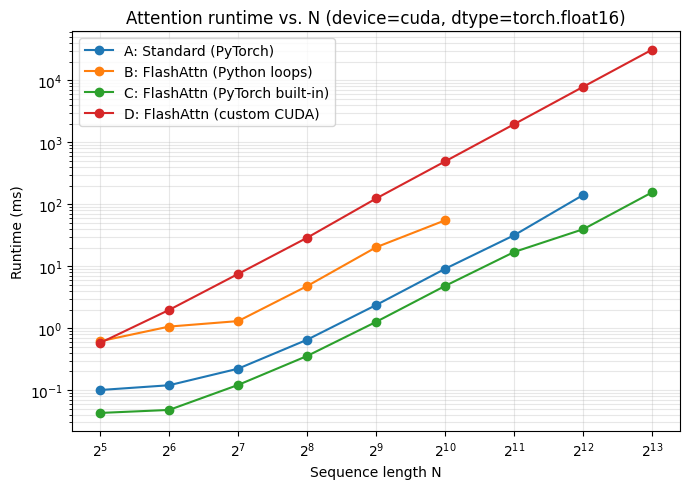

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
for label, res in [("A: Standard (PyTorch)", results_a),
                    ("B: FlashAttn (Python loops)", results_b),
                    ("C: FlashAttn (PyTorch built-in)", results_c),
                    ("D: FlashAttn (custom CUDA)", results_d)]:
    if not res:
        continue
    ns = [r[0] for r in res]
    ms = [r[1] for r in res]
    plt.plot(ns, ms, marker="o", label=label)
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Sequence length N")
plt.ylabel("Runtime (ms)")
plt.title(f"Attention runtime vs. N (device={DEVICE}, dtype={DTYPE})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("runtime_vs_n.png", dpi=150)
plt.show()
